# FastQC QC bundle analysis (qc_bundle)

Goal: summarize FastQC results across all samples, identify consistent QC issues and problematic files, and generate plots/tables you can use for team decisions (trim/filter vs leave as-is).

Input directory: `/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle`

Note: FastQC HTML reports are generated from the same underlying files contained in each `*_fastqc.zip`. For reproducible parsing, this notebook reads the `zip` contents (`summary.txt` + `fastqc_data.txt`) and uses the HTML only as a human-readable report.

# FastQC QC bundle analysis (zebrafish)

This notebook analyzes FastQC outputs for PRJNA1277581 zebrafish SRR runs.
Each paired-end SRR produces two FastQC reports (`_1` and `_2`), so 30 SRRs correspond to 60 reports.


## Dataset identifiers (zebrafish project)

- BioProject: `PRJNA1277581` (Danio rerio, TaxID 7955)
- SRA Study: `SRP592470`
- GEO Series (our dataset): `GSE299935`
- Note: `GSE145330` is a different GEO series and does **not** match this project.

Example mapping (one run): `SRR34002410` → `GSM9050449` → `GSE299935`.


In [ ]:
import csv
import io
import re
import urllib.request

def fetch_runinfo(run):
    url = f'https://trace.ncbi.nlm.nih.gov/Traces/sra-db-be/runinfo?acc={run}'
    text = urllib.request.urlopen(url, timeout=30).read().decode('utf-8')
    row = next(csv.DictReader(io.StringIO(text)))
    return row

def fetch_gse_from_gsm(gsm):
    url = f'https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc={gsm}&targ=self&form=text&view=quick'
    txt = urllib.request.urlopen(url, timeout=30).read().decode('utf-8', errors='replace')
    m = re.search(r'!Sample_series_id\s*=\s*(GSE\d+)', txt)
    return m.group(1) if m else None

run = 'SRR34002410'
info = fetch_runinfo(run)
gsm = info.get('LibraryName') or info.get('SampleName')
gse = fetch_gse_from_gsm(gsm) if gsm and gsm.startswith('GSM') else None
print({'run': run, 'gsm': gsm, 'gse': gse, 'BioProject': info.get('BioProject'), 'SRAStudy': info.get('SRAStudy')})


## Environment setup (one-time)

This notebook needs: `pandas`, `numpy`, `matplotlib`, `seaborn`.

If you're already reportning Jupyter from your project environment (recommended), install once:

```bash
python -m pip install pandas numpy matplotlib seaborn
```

If your `python` is Homebrew-managed and refuses installs (PEP 668), use a venv:

```bash
cd /Users/pitergarcia/DataScience
python -m venv .venv_fastqc
source .venv_fastqc/bin/activate
python -m pip install pandas numpy matplotlib seaborn
```


In [1]:
import sys
import re
import csv
import zipfile
from pathlib import Path
from collections import defaultdict

qc_dir = Path('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle')
out_dir = qc_dir / 'qc_analysis'
out_dir.mkdir(parents=True, exist_ok=True)

required = ['pandas', 'numpy', 'matplotlib', 'seaborn']
missing = []
for name in required:
    try:
        __import__(name)
    except Exception:
        missing.append(name)

if missing:
    msg = (
        'Missing Python packages: ' + ', '.join(missing) + '\n'
        'Install them in your current environment, then re-run this cell.\n\n'
        'If you are in conda/venv:  python -m pip install pandas numpy matplotlib seaborn\n'
        'If you are on Homebrew Python (PEP 668):\n'
        '  python -m venv .venv_fastqc\n'
        '  source .venv_fastqc/bin/activate\n'
        '  python -m pip install pandas numpy matplotlib seaborn\n'
    )
    raise RuntimeError(msg)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image

sns.set_theme(style='whitegrid')

zips_all = sorted(qc_dir.rglob('*_fastqc.zip'))
zips = [p for p in zips_all if p.name.startswith('SRR')]

report_count = len(zips)
srr_ids = sorted({p.name.split('_')[0] for p in zips})
srr_count = len(srr_ids)
paired_expected = report_count == 2 * srr_count
pd.DataFrame([{'fastqc_reports': report_count, 'srr_runs': srr_count, 'paired_expected': paired_expected}])
pd.DataFrame({'srr': srr_ids}).head(30)

42

## Step 1 — Parse FastQC ZIPs

We extract two things from each zip:

- `summary.txt`: module-level PASS/WARN/FAIL
- `fastqc_data.txt`: numeric details for selected modules


In [2]:
status_rank = {'pass': 0, 'warn': 1, 'fail': 2}

def infer_sample_fields(zip_path: Path):
    name = zip_path.name
    stage = 'trimmed' if 'trim' in name.lower() or 'trimmed' in str(zip_path).lower() else 'raw'
    m = re.match(r'^(?P<id>.+?)_(?P<read>[12])_fastqc\.zip$', name)
    if m:
        return m.group('id'), m.group('read'), stage
    m = re.match(r'^(?P<id>.+?)\.trim_fastqc\.zip$', name)
    if m:
        return m.group('id'), None, stage
    return name.replace('_fastqc.zip',''), None, stage

def read_zip_text(z: zipfile.ZipFile, suffix: str):
    for member in z.namelist():
        if member.endswith(suffix):
            return z.read(member).decode('utf-8', errors='replace')
    raise FileNotFoundError(suffix)

def parse_summary_txt(text: str):
    rows = []
    for line in text.splitlines():
        parts = line.split('\t')
        if len(parts) >= 2:
            rows.append({'status': parts[0].strip().lower(), 'module': parts[1].strip()})
    return rows

def parse_basic_stats(module_lines):
    stats = {}
    for row in module_lines:
        if len(row) >= 2:
            stats[row[0]] = row[1]
    return stats

def parse_fastqc_data(text: str):
    modules = {}
    current = None
    current_status = None
    buffer = []
    for line in text.splitlines():
        if line.startswith('>>END_MODULE'):
            if current is not None:
                modules[current] = {'status': current_status, 'lines': buffer}
            current = None
            current_status = None
            buffer = []
            continue
        if line.startswith('>>'):
            header = line[2:]
            parts = header.split('\t')
            current = parts[0].strip()
            current_status = parts[1].strip().lower() if len(parts) > 1 else None
            buffer = []
            continue
        if current is not None:
            buffer.append(line)
    return modules

def table_from_module_lines(lines):
    lines = [ln for ln in lines if ln]
    if not lines:
        return []

    header_i = None
    for i, ln in enumerate(lines):
        if '\t' not in ln:
            continue
        if ln.startswith('#Total '):
            continue
        if ln.startswith('#Total\t'):
            continue
        if ln.startswith('#Total'):
            continue
        header_i = i
        break

    if header_i is None:
        return []

    header = lines[header_i].lstrip('#').split('\t')
    out = []
    for ln in lines[header_i + 1:]:
        if not ln or ln.startswith('#'):
            continue
        parts = ln.split('\t')
        if len(parts) != len(header):
            continue
        out.append(dict(zip(header, parts)))
    return out

def to_float(x):
    try:
        return float(x)
    except Exception:
        return np.nan

records = []
module_status_rows = []
metrics_map = {}
overrep_rows = []

for zp in zips:
    sample_id, read_id, stage = infer_sample_fields(zp)
    with zipfile.ZipFile(zp, 'r') as z:
        summary = parse_summary_txt(read_zip_text(z, 'summary.txt'))
        data = parse_fastqc_data(read_zip_text(z, 'fastqc_data.txt'))

    report_id = f'{sample_id}_{read_id}' if read_id else f'{sample_id}'
    records.append({'report_id': report_id, 'sample': sample_id, 'read': read_id, 'stage': stage, 'zip': str(zp)})

    mk = (stage, report_id)
    if mk not in metrics_map:
        metrics_map[mk] = {'report_id': report_id, 'stage': stage}

    for row in summary:
        if row['status'] in status_rank:
            module_status_rows.append({'report_id': report_id, 'stage': stage, 'module': row['module'], 'status': row['status']})

    basic = data.get('Basic Statistics')
    if basic:
        rows = table_from_module_lines(basic['lines'])
        stats = parse_basic_stats([[r.get('Measure',''), r.get('Value','')] for r in rows])
        metrics_map[mk].update(stats)

    pbq = data.get('Per base sequence quality')
    if pbq:
        rows = table_from_module_lines(pbq['lines'])
        if rows:
            tenth = [to_float(r.get('10th Percentile','')) for r in rows]
            meanq = [to_float(r.get('Mean','')) for r in rows]
            metrics_map[mk].update({
                'pbq_min_10th': np.nanmin(tenth) if np.any(~np.isnan(tenth)) else np.nan,
                'pbq_min_mean': np.nanmin(meanq) if np.any(~np.isnan(meanq)) else np.nan
            })

    adap = data.get('Adapter Content')
    if adap:
        rows = table_from_module_lines(adap['lines'])
        if rows:
            adapter_cols = [c for c in rows[0].keys() if c != 'Position']
            vals = []
            for r in rows:
                for c in adapter_cols:
                    vals.append(to_float(r.get(c,'')))
            metrics_map[mk].update({'adapter_max': np.nanmax(vals) if vals else np.nan})

    dup = data.get('Sequence Duplication Levels')
    if dup:
        lines = [ln for ln in dup['lines'] if ln and not ln.startswith('#')]
        dedup = np.nan
        for ln in lines[:20]:
            if 'Total Deduplicated Percentage' in ln:
                parts = ln.split('\t')
                if len(parts) >= 2:
                    dedup = to_float(parts[1])
        metrics_map[mk].update({'deduplicated_pct': dedup})

    over = data.get('Overrepresented sequences')
    if over:
        rows = table_from_module_lines(over['lines'])
        for r in rows[:50]:
            out = {'report_id': report_id, 'stage': stage}
            out.update(r)
            overrep_rows.append(out)

meta_df = pd.DataFrame(records)
status_df = pd.DataFrame(module_status_rows)
metrics_df = pd.DataFrame(list(metrics_map.values()))
overrep_df = pd.DataFrame(overrep_rows)

meta_df.head()


,report_id,sample,read,stage,zip
0,SRR34002411_1,SRR34002411,1,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
1,SRR34002411_2,SRR34002411,2,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
2,SRR34002413_1,SRR34002413,1,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
3,SRR34002413_2,SRR34002413,2,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...
4,SRR34002414_1,SRR34002414,1,raw,/Users/pitergarcia/DataScience/Semester5/BIOL5...


## Step 2 — Build QC tables

In [3]:
modules = sorted(status_df['module'].unique())
status_pivot = status_df.pivot_table(index=['stage','report_id'], columns='module', values='status', aggfunc='first')
status_numeric = status_pivot.replace(status_rank).apply(pd.to_numeric, errors='coerce')

metrics_wide = metrics_df.groupby(['stage','report_id']).last().reset_index()
metrics_wide = metrics_wide.merge(meta_df[['stage','report_id','sample','read']], on=['stage','report_id'], how='left')

status_numeric.shape, metrics_wide.shape

/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_50923/2582065202.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  status_numeric = status_pivot.replace(status_rank).apply(pd.to_numeric, errors='coerce')


((42, 11), (42, 15))

## Step 3 — Identify consistent issues and problematic files

In [4]:
counts = []
for m in modules:
    col = status_pivot[m]
    counts.append({
        'module': m,
        'pass': int((col == 'pass').sum()),
        'warn': int((col == 'warn').sum()),
        'fail': int((col == 'fail').sum()),
        'n': int(col.notna().sum())
    })
module_counts = pd.DataFrame(counts).sort_values(['fail','warn'], ascending=False)
module_counts.head(15)

,module,pass,warn,fail,n
9,Sequence Duplication Levels,0,0,42,42
6,Per sequence GC content,0,22,20,42
0,Adapter Content,20,2,20,42
4,Per base sequence content,0,26,16,42
2,Overrepresented sequences,0,42,0,42
8,Per tile sequence quality,39,3,0,42
1,Basic Statistics,42,0,0,42
3,Per base N content,42,0,0,42
5,Per base sequence quality,42,0,0,42
7,Per sequence quality scores,42,0,0,42


In [5]:
status_scores = status_numeric.copy()
status_scores['fail_count'] = (status_pivot == 'fail').sum(axis=1)
status_scores['warn_count'] = (status_pivot == 'warn').sum(axis=1)
status_scores['severity'] = status_scores['fail_count']*3 + status_scores['warn_count']
top_problematic = status_scores[['fail_count','warn_count','severity']].sort_values(['severity','fail_count'], ascending=False).head(25)
top_problematic

module               fail_count  warn_count  severity
stage report_id                                      
raw   SRR34002417_1           3           2        11
      SRR34002418_1           3           2        11
      SRR34002418_2           3           2        11
      SRR34002420_1           3           2        11
      SRR34002420_2           3           2        11
      SRR34002426_2           3           2        11
      SRR34002427_2           3           2        11
      SRR34002429_2           3           2        11
      SRR34002413_1           3           1        10
      SRR34002432_2           3           1        10
      SRR34002433_2           3           1        10
      SRR34002435_1           3           1        10
      SRR34002437_1           3           1        10
      SRR34002439_1           3           1        10
      SRR34002413_2           2           3         9
      SRR34002414_2           2           3         9
      SRR34002416_1           2           3         9
      SRR34002416_2           2           3         9
      SRR34002417_2           2           3         9
      SRR34002421_1           2           3         9
      SRR34002421_2           2           3         9
      SRR34002423_1           2           3         9
      SRR34002423_2           2           3         9
      SRR34002424_1           2           3         9
      SRR34002424_2           2           3         9

## Step 4 — Visualizations

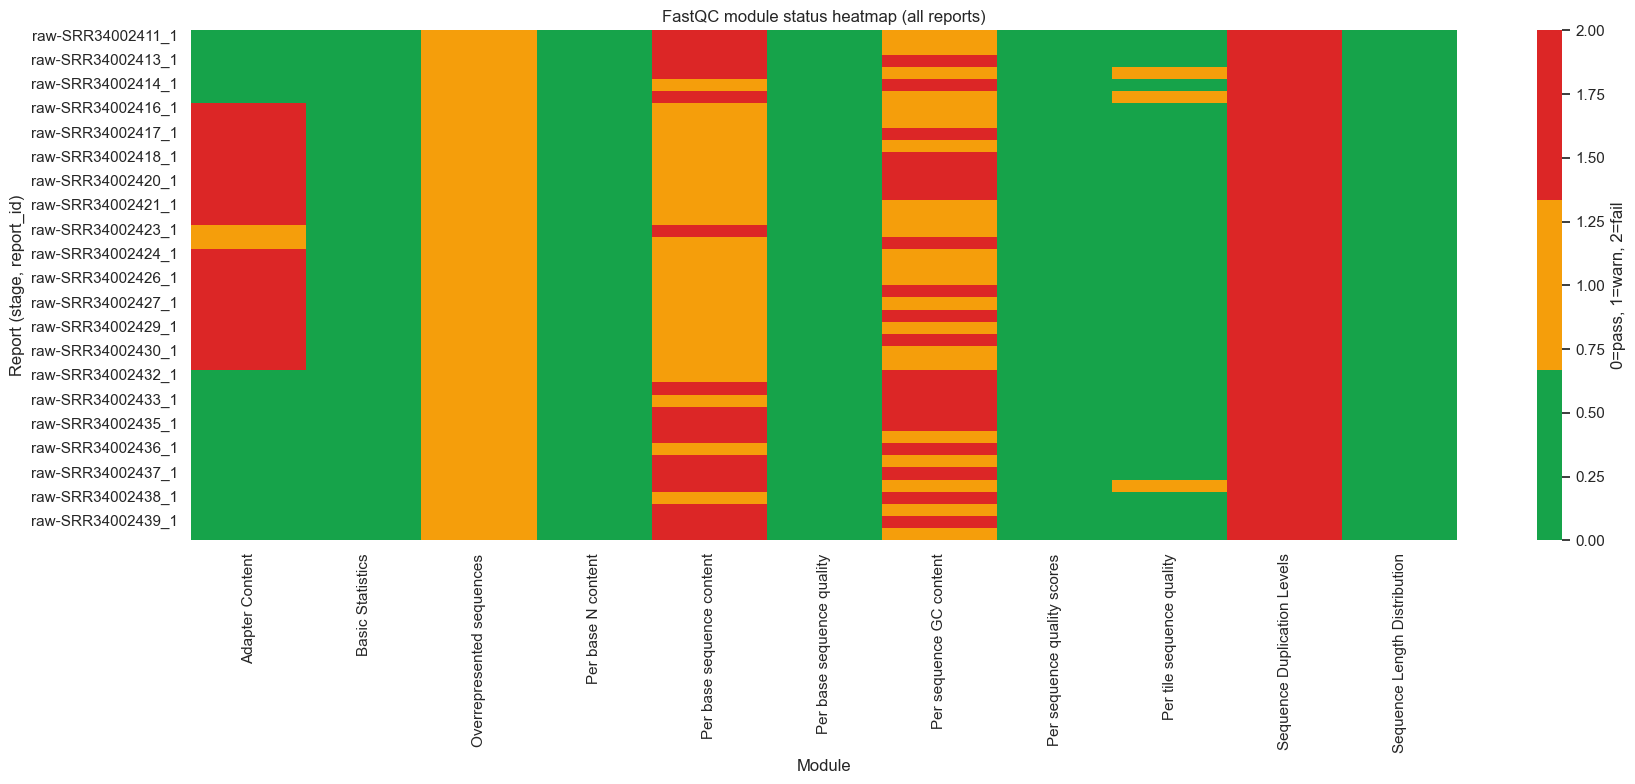

In [6]:
plt.figure(figsize=(18, 8))
sns.heatmap(status_numeric.fillna(0), cmap=sns.color_palette(['#16a34a','#f59e0b','#dc2626'], as_cmap=True), cbar_kws={'label': '0=pass, 1=warn, 2=fail'})
plt.title('FastQC module status heatmap (all reports)')
plt.xlabel('Module')
plt.ylabel('Report (stage, report_id)')
plt.tight_layout()
plt.savefig(out_dir / 'fastqc_module_status_heatmap.png', dpi=200)
plt.show()

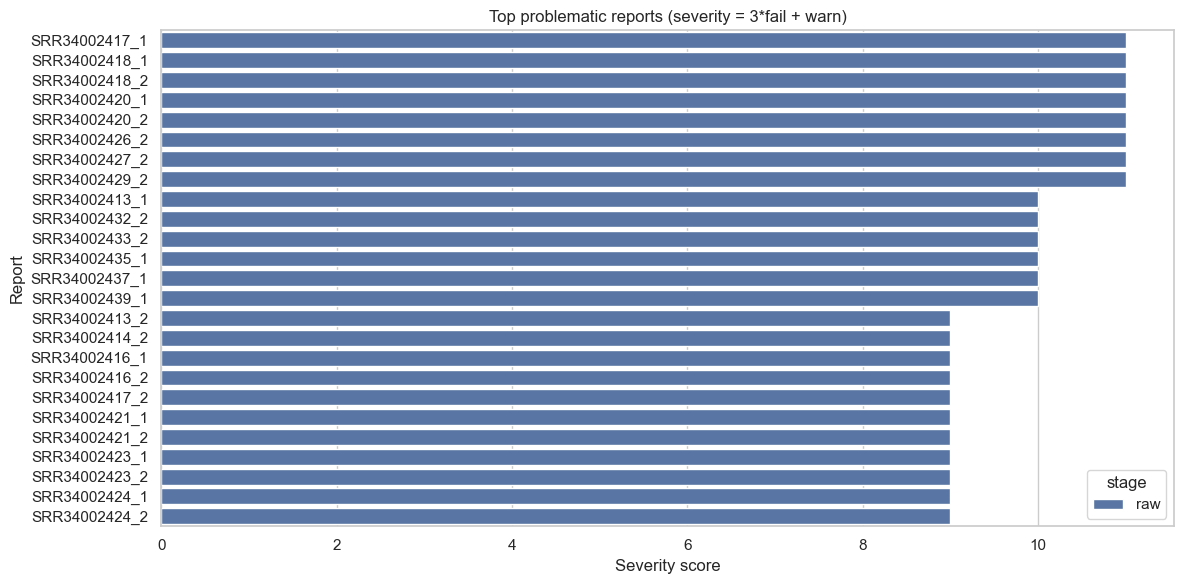

In [7]:
problematic_df = top_problematic.reset_index()
problematic_df = problematic_df.merge(meta_df[['stage','report_id','sample','read']], on=['stage','report_id'], how='left')
plt.figure(figsize=(12, 6))
sns.barplot(data=problematic_df, x='severity', y='report_id', hue='stage', dodge=False)
plt.title('Top problematic reports (severity = 3*fail + warn)')
plt.xlabel('Severity score')
plt.ylabel('Report')
plt.tight_layout()
plt.savefig(out_dir / 'fastqc_top_problematic_reports.png', dpi=200)
plt.show()

## Step 5 — Key quantitative signals (quality tail, adapters, duplication, overrepresented sequences)

In [8]:
key_cols = ['pbq_min_10th','pbq_min_mean','adapter_max','deduplicated_pct','%GC','Sequence length','Total Sequences']
available = [c for c in key_cols if c in metrics_wide.columns]
metrics_wide[available].describe(include='all')

,pbq_min_10th,pbq_min_mean,adapter_max,deduplicated_pct,%GC,Sequence length,Total Sequences
count,42.000000,42.000000,42.000000,0.0,42,42,42
unique,NaN,NaN,NaN,NaN,9,1,21
top,NaN,NaN,NaN,NaN,46,151,115735928
freq,NaN,NaN,NaN,NaN,15,42,2
mean,21.297619,34.909352,7.391610,NaN,NaN,NaN,NaN
std,5.372763,1.479925,6.283210,NaN,NaN,NaN,NaN
min,11.000000,32.392207,0.548303,NaN,NaN,NaN,NaN
25%,19.500000,33.993932,1.105120,NaN,NaN,NaN,NaN
50%,24.000000,35.627395,9.340324,NaN,NaN,NaN,NaN
75%,24.000000,36.251362,13.207744,NaN,NaN,NaN,NaN


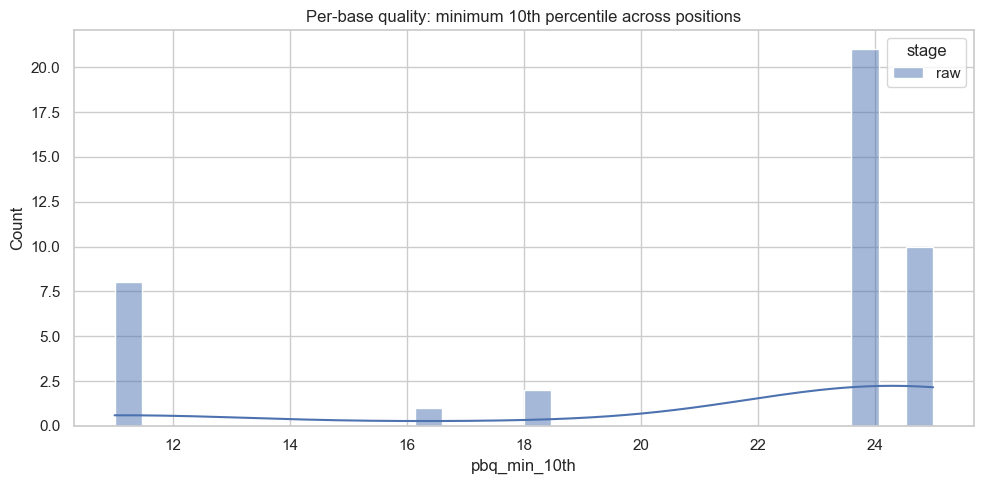

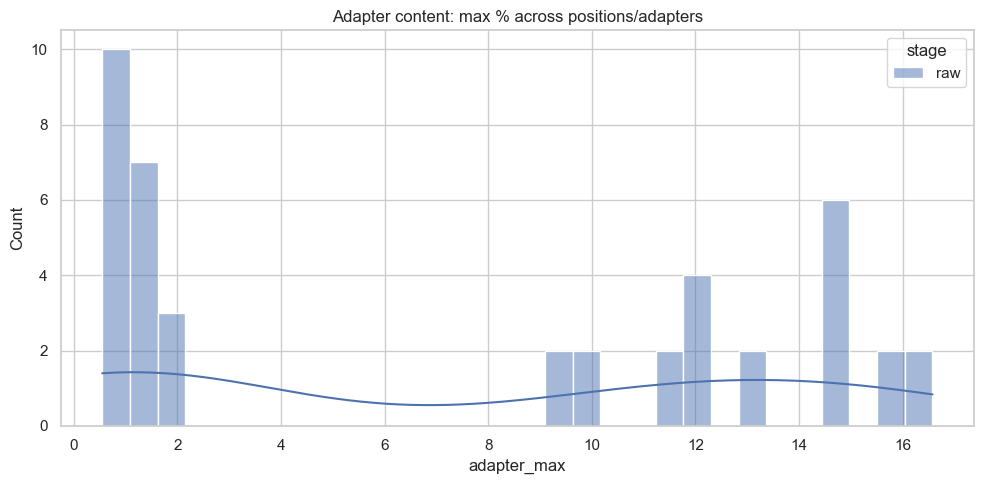

In [9]:
plot_df = metrics_wide.copy()
if 'pbq_min_10th' in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=plot_df, x='pbq_min_10th', hue='stage', bins=30, kde=True)
    plt.title('Per-base quality: minimum 10th percentile across positions')
    plt.tight_layout()
    plt.savefig(out_dir / 'pbq_min_10th_hist.png', dpi=200)
    plt.show()

if 'adapter_max' in plot_df.columns:
    plt.figure(figsize=(10, 5))
    sns.histplot(data=plot_df, x='adapter_max', hue='stage', bins=30, kde=True)
    plt.title('Adapter content: max % across positions/adapters')
    plt.tight_layout()
    plt.savefig(out_dir / 'adapter_max_hist.png', dpi=200)
    plt.show()

In [10]:
if not overrep_df.empty:
    cols = [c for c in ['report_id','stage','Sequence','Count','Percentage','Possible Source'] if c in overrep_df.columns]
    display(overrep_df[cols].head(30))
    overrep_df.to_csv(out_dir / 'fastqc_overrepresented_sequences.csv', index=False)

,report_id,stage,Sequence,Count,Percentage,Possible Source
0,SRR34002411_1,raw,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,506386,0.43753569764438227,No Hit
1,SRR34002411_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG...,345796,0.29878016790084405,No Hit
2,SRR34002413_1,raw,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,625923,0.5817502984323274,No Hit
3,SRR34002413_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG...,142573,0.13251132375450692,No Hit
4,SRR34002414_1,raw,TTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTTT...,580570,0.4237227057953862,No Hit
5,SRR34002414_1,raw,GTTCAGATCGGAAGAGCACACGTCTGAACTCCAGTCACACCAGTGA...,149014,0.10875624865458718,"TruSeq Adapter, Index 1 (97% over 37bp)"
6,SRR34002414_2,raw,GGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGGG...,768306,0.5607397853813149,No Hit
7,SRR34002414_2,raw,GAACAGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGTCCACCTAAG...,150649,0.10994953563802665,Illumina Single End PCR Primer 1 (96% over 33bp)
8,SRR34002416_1,raw,GATCGGAAGAGCACACGTCTGAACTCCAGTCACTAGGGACCATCTG...,141633,0.25909819128669936,"TruSeq Adapter, Index 7 (97% over 36bp)"
9,SRR34002416_1,raw,GATCGGAAGAGCACACGTCTGAACTCCAGTCACTAGGGACCATCTA...,57277,0.104780433248807,"TruSeq Adapter, Index 7 (97% over 36bp)"


## Step 6 — Export summary tables

In [11]:
module_counts.to_csv(out_dir / 'fastqc_module_counts.csv', index=False)
status_pivot.to_csv(out_dir / 'fastqc_status_by_report.csv')
metrics_wide.to_csv(out_dir / 'fastqc_metrics_by_report.csv', index=False)
top_problematic.to_csv(out_dir / 'fastqc_top_problematic_reports.csv')

sorted(out_dir.glob('fastqc_*'))[:10]

[PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_metrics_by_report.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_module_counts.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_module_status_heatmap.png'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_overrepresented_sequences.csv'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_per_sequence_gc_content_all.png'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_sequence_duplication_levels_all.png'),
 PosixPath('/Users/pitergarcia/DataScience/Semester5/BIOL550/group_project/qc_bundle/qc_analysis/fastqc_sequence_length_distribution_all.png'),
 PosixPath('/Users/pitergarcia/DataScience/Semeste

In [12]:
action_map = pd.DataFrame([
  {'FastQC module': 'Per base sequence quality', 'Typical meaning': 'Base qualities drop by cycle (often at read ends)', 'Common cause': 'Sequencing quality decay, long reads', 'Suggested action': 'Quality trim (FASTX fastq_quality_trimmer or Trimmomatic sliding window)'},
  {'FastQC module': 'Adapter Content', 'Typical meaning': 'Adapter sequences detected in reads', 'Common cause': 'Short inserts, read-through, adapter dimers', 'Suggested action': 'Adapter clipping (FASTX fastx_clipper or Trimmomatic adapters)'},
  {'FastQC module': 'Overrepresented sequences', 'Typical meaning': 'Specific sequences appear unusually often', 'Common cause': 'Adapters/primers, rRNA, contamination, low complexity', 'Suggested action': 'If adapter/primer: clip; otherwise inspect sources and consider filtering'},
  {'FastQC module': 'Sequence Duplication Levels', 'Typical meaning': 'High duplication / low unique fraction', 'Common cause': 'Low library complexity, PCR duplicates, highly expressed transcripts', 'Suggested action': 'Flag for interpretation; trimming rarely fixes; consider dedup only if appropriate'},
  {'FastQC module': 'Per base sequence content', 'Typical meaning': 'A/C/G/T bias by position', 'Common cause': 'Priming bias, library prep artifacts', 'Suggested action': 'Often acceptable for RNA-seq; document; consider trimming first bases if extreme'},
  {'FastQC module': 'Per sequence GC content', 'Typical meaning': 'GC distribution deviates from expectation', 'Common cause': 'Contamination, biased library', 'Suggested action': 'Compare across samples; if outliers, investigate contamination'},
  {'FastQC module': 'Kmer Content', 'Typical meaning': 'Enriched kmers at specific positions', 'Common cause': 'Adapters/primers, poly-A/T tails', 'Suggested action': 'Often resolves with adapter/quality trimming'}
])
action_map

,FastQC module,Typical meaning,Common cause,Suggested action
0,Per base sequence quality,Base qualities drop by cycle (often at read ends),"Sequencing quality decay, long reads",Quality trim (FASTX fastq_quality_trimmer or T...
1,Adapter Content,Adapter sequences detected in reads,"Short inserts, read-through, adapter dimers",Adapter clipping (FASTX fastx_clipper or Trimm...
2,Overrepresented sequences,Specific sequences appear unusually often,"Adapters/primers, rRNA, contamination, low com...",If adapter/primer: clip; otherwise inspect sou...
3,Sequence Duplication Levels,High duplication / low unique fraction,"Low library complexity, PCR duplicates, highly...",Flag for interpretation; trimming rarely fixes...
4,Per base sequence content,A/C/G/T bias by position,"Priming bias, library prep artifacts",Often acceptable for RNA-seq; document; consid...
5,Per sequence GC content,GC distribution deviates from expectation,"Contamination, biased library","Compare across samples; if outliers, investiga..."
6,Kmer Content,Enriched kmers at specific positions,"Adapters/primers, poly-A/T tails",Often resolves with adapter/quality trimming


## Step 6.5 — SRR-level “problem list” by FastQC module
Summarize zebrafish SRR flags by taking the worst status across the paired-end reports (`_1` and `_2`) for each module.
This section uses `module_key` (snake_case) to match slide labels and prints a Markdown table at SRR level (one row per SRR per flagged module).


In [ ]:
status_rank = {'pass': 0, 'warn': 1, 'fail': 2}
rank_to_status = {0: 'pass', 1: 'warn', 2: 'fail'}

module_key_map = {
    'Adapter Content': 'adapter_content',
    'Basic Statistics': 'basic_statistics',
    'Kmer Content': 'kmer_content',
    'Overrepresented sequences': 'overrepresented_sequences',
    'Per base N content': 'per_base_n_content',
    'Per base sequence content': 'per_base_sequence_content',
    'Per base sequence quality': 'per_base_sequence_quality',
    'Per sequence GC content': 'per_sequence_gc_content',
    'Per sequence quality scores': 'per_sequence_quality_scores',
    'Per tile sequence quality': 'per_tile_sequence_quality',
    'Sequence Duplication Levels': 'sequence_duplication_levels',
    'Sequence Length Distribution': 'sequence_length_distribution'
}


status_with_meta = status_df.merge(
    meta_df[['stage', 'report_id', 'sample', 'read']],
    on=['stage', 'report_id'],
    how='left'
)

status_with_meta = status_with_meta[status_with_meta['sample'].notna()]
status_with_meta = status_with_meta[status_with_meta['sample'].astype(str).str.startswith('SRR')]
status_with_meta['srr'] = status_with_meta['sample'].astype(str)
status_with_meta['rank'] = status_with_meta['status'].map(status_rank)

srr_level = (
    status_with_meta
    .groupby(['stage', 'srr', 'module'], as_index=False)['rank']
    .max()
)
srr_level['status'] = srr_level['rank'].map(rank_to_status)
srr_level['module_key'] = srr_level['module'].map(module_key_map).fillna(
    srr_level['module'].astype(str)
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

module_guide = pd.DataFrame([
    {
        'module': 'Per base sequence quality',
        'issue': 'Quality drops at certain cycles (often toward read ends)',
        'desc': 'Low base-call quality by position can hurt alignment and downstream quantification.',
        'possible_causes': 'Sequencing quality decay, long reads, instrument effects.',
        'possible_solutions': 'Quality-trim tails (FASTX fastq_quality_trimmer) and/or filter low-mean-quality reads (FASTX fastq_quality_filter); run FastQC again.'
    },
    {
        'module': 'Sequence Length Distribution',
        'issue': 'Read lengths are consistent or vary across reads',
        'desc': 'Unexpected variability pre-trim can indicate mixed inputs or prior processing; post-trim variability is normal.',
        'possible_causes': 'Prior trimming, mixed read types, partial reads.',
        'possible_solutions': 'If pre-trim variability is unexpected, inspect inputs; after trimming, ensure lengths are not extremely shortened (mappability risk).'
    },
    {
        'module': 'Adapter Content',
        'issue': 'Adapter sequence detected in reads',
        'desc': 'Adapters inflate k-mer signals and can create artificial sequence content bias.',
        'possible_causes': 'Short inserts/read-through, adapter dimers, incomplete cleanup.',
        'possible_solutions': 'Clip adapters with FASTX fastx_clipper (correct adapter sequence) and run FastQC again.'
    },
    {
        'module': 'Overrepresented sequences',
        'issue': 'Specific sequences appear far more often than expected',
        'desc': 'Often indicates adapters/primers or a small number of very frequent sequences.',
        'possible_causes': 'Residual adapters/primers, rRNA/contamination, low-complexity, real highly expressed transcripts.',
        'possible_solutions': 'Identify sequences first (FastQC list); if adapters/primers clip; if rRNA/contaminant consider filtering/flagging; if biological transcript document as expected.'
    },
    {
        'module': 'Sequence Duplication Levels',
        'issue': 'Many duplicate reads / low unique fraction',
        'desc': 'In RNA-seq, duplication can be biological (high expression) but extreme outliers can indicate low complexity/PCR artifacts.',
        'possible_causes': 'Highly expressed genes (common), PCR duplication, low library complexity.',
        'possible_solutions': 'Do not trim to fix; compare across SRRs and flag extreme outliers; consider excluding/redownloading or redoing a library if clearly worse.'
    },
    {
        'module': 'Per base sequence content',
        'issue': 'A/C/G/T positional bias across cycles',
        'desc': 'Position-specific base composition bias is common in RNA-seq but outliers can indicate prep artifacts.',
        'possible_causes': 'Random-priming bias, library prep artifacts, poly-A/T signal, adapters/primers.',
        'possible_solutions': 'Usually document; if tied to adapters/primers, clip; investigate only if a subset are strong outliers.'
    },
    {
        'module': 'Per sequence GC content',
        'issue': 'GC distribution differs from expectation',
        'desc': 'FastQC may warn/fail due to transcriptome composition; worry mainly about shifts/second peaks in a subset.',
        'possible_causes': 'Transcriptome composition/expression bias, library bias; sometimes contamination.',
        'possible_solutions': 'Compare GC curves across SRRs; if outliers persist after trimming, flag as possible contamination/batch effect.'
    },
    {
        'module': 'Per tile sequence quality',
        'issue': 'Tile-level quality variation',
        'desc': 'A small subset of tiles have worse quality, usually an instrument/flowcell effect.',
        'possible_causes': 'Flowcell/instrument tile issues.',
        'possible_solutions': 'Mostly note and proceed; flag if it co-occurs with other strong QC issues.'
    },
    {
        'module': 'Per base N content',
        'issue': 'Ambiguous base calls (N) at positions',
        'desc': 'High N content indicates base calling uncertainty and can reduce alignment quality.',
        'possible_causes': 'Low quality cycles, instrument issues.',
        'possible_solutions': 'If flagged, quality-trim/filter; otherwise ignore if pass.'
    },
    {
        'module': 'Basic Statistics',
        'issue': 'Basic library summary',
        'desc': 'Sanity checks: read counts, length, %GC.',
        'possible_causes': 'N/A',
        'possible_solutions': 'If flagged, verify inputs and file integrity.'
    }
])

module_guide['module_key'] = module_guide['module'].map(module_key_map).fillna(
    module_guide['module'].astype(str)
    .str.lower()
    .str.replace(r'[^a-z0-9]+', '_', regex=True)
    .str.strip('_')
)

problem_long = srr_level[srr_level['status'].isin(['warn', 'fail'])].merge(module_guide, on=['module', 'module_key'], how='left')
problem_long = problem_long.sort_values(['module_key', 'status', 'srr'])

counts_by_module = (
    srr_level
    .groupby(['module_key', 'module', 'status'], as_index=False)
    .size()
    .rename(columns={'size': 'srr_count'})
    .sort_values(['module_key', 'status'])
)

severity_by_report = (
    status_with_meta
    .groupby(['stage', 'report_id', 'srr'], as_index=False)
    .agg(
        fail_count=('status', lambda x: int((x == 'fail').sum())),
        warn_count=('status', lambda x: int((x == 'warn').sum()))
    )
)
severity_by_report['severity'] = severity_by_report['fail_count'] * 3 + severity_by_report['warn_count']

severity_by_srr = (
    severity_by_report
    .groupby(['stage', 'srr'], as_index=False)
    .agg(
        severity=('severity', 'sum'),
        fail_total=('fail_count', 'sum'),
        warn_total=('warn_count', 'sum')
    )
    .sort_values(['severity'], ascending=False)
)

fail_mods = (
    srr_level[srr_level['status'] == 'fail']
    .groupby(['stage', 'srr'], as_index=False)
    .agg(fail_modules=('module_key', lambda x: ', '.join(sorted(set(x)))))
)

warn_mods = (
    srr_level[srr_level['status'] == 'warn']
    .groupby(['stage', 'srr'], as_index=False)
    .agg(warn_modules=('module_key', lambda x: ', '.join(sorted(set(x)))))
)

severity_by_srr = severity_by_srr.merge(fail_mods, on=['stage', 'srr'], how='left').merge(warn_mods, on=['stage', 'srr'], how='left')
severity_by_srr['fail_modules'] = severity_by_srr['fail_modules'].fillna('')
severity_by_srr['warn_modules'] = severity_by_srr['warn_modules'].fillna('')



def df_to_markdown_table(df):
    cols = list(df.columns)
    out = []
    out.append('| ' + ' | '.join(cols) + ' |')
    out.append('| ' + ' | '.join(['---'] * len(cols)) + ' |')
    for _, r in df.fillna('').iterrows():
        row = []
        for c in cols:
            v = str(r[c]).replace('\n', ' ').replace('|', '\|')
            row.append(v)
        out.append('| ' + ' | '.join(row) + ' |')
    return '\n'.join(out)

srr_status_wide = (
    srr_level
    .pivot_table(index=['stage', 'srr'], columns='module_key', values='status', aggfunc='first')
    .reset_index()
)

srr_status_wide.to_csv(out_dir / 'fastqc_status_by_srr_module_wide.csv', index=False)
(out_dir / 'fastqc_status_by_srr_module_wide.md').write_text(df_to_markdown_table(srr_status_wide))

def join_srrs(x):
    return ', '.join(sorted(set(x)))

problem_srrs_by_module = (
    srr_level[srr_level['status'].isin(['warn', 'fail'])]
    .groupby(['module_key', 'module', 'status'], as_index=False)
    .agg(srrs=('srr', join_srrs), srr_count=('srr', lambda x: len(set(x))))
    .sort_values(['module_key', 'status'])
)



status_score = {'pass': 0, 'warn': 1, 'fail': 3}

srr_status_long = (
    srr_level
    .loc[:, ['stage', 'srr', 'module_key', 'module', 'status']]
    .assign(severity_score=lambda d: d['status'].map(status_score).fillna(0).astype(int))
    .sort_values(['stage', 'srr', 'module_key'])
)

srr_status_long.to_csv(out_dir / 'fastqc_status_by_srr_module_long.csv', index=False)
(out_dir / 'fastqc_status_by_srr_module_long.md').write_text(df_to_markdown_table(srr_status_long))

display(srr_status_long.head(60))

problem_srrs_by_module.to_csv(out_dir / 'fastqc_problem_srrs_by_module.csv', index=False)
(out_dir / 'fastqc_problem_srrs_by_module.md').write_text(df_to_markdown_table(problem_srrs_by_module))

problem_long.to_csv(out_dir / 'fastqc_problem_table_srr_level.csv', index=False)
counts_by_module.to_csv(out_dir / 'fastqc_module_status_by_srr.csv', index=False)
severity_by_srr.to_csv(out_dir / 'fastqc_top_severity_srrs.csv', index=False)

cols = ['module_key', 'module', 'status', 'srr', 'issue', 'desc', 'possible_causes', 'possible_solutions']

md_lines = []
md_lines.append('| ' + ' | '.join(cols) + ' |')
md_lines.append('| ' + ' | '.join(['---'] * len(cols)) + ' |')

for _, r in problem_long[cols].fillna('').iterrows():
    row = []
    for c in cols:
        v = str(r[c])
        v = v.replace('\n', ' ')
        v = v.replace('|', '\|')
        row.append(v)
    md_lines.append('| ' + ' | '.join(row) + ' |')

md_table = '\n'.join(md_lines)
(out_dir / 'fastqc_problem_table_srr_level.md').write_text(md_table)

from IPython.display import Markdown

display(Markdown(md_table))
display(problem_long.head(30))
display(counts_by_module)
display(severity_by_srr.head(15))


## Step 6.6 — WARN/FAIL modules per SRR (run-level)

Two views: (1) long format (one row per SRR per flagged module), and (2) per-SRR summary lists of WARN vs FAIL module keys.

In [ ]:
per_srr_module = (
    srr_level[srr_level['status'].isin(['warn', 'fail'])]
    .loc[:, ['stage', 'srr', 'module_key', 'module', 'status']]
    .sort_values(['stage', 'srr', 'status', 'module_key'])
)

per_srr_status_lists = (
    per_srr_module
    .groupby(['stage', 'srr', 'status'], as_index=False)
    .agg(
        module_keys=('module_key', lambda x: ', '.join(sorted(set(x)))),
        module_names=('module', lambda x: ', '.join(sorted(set(x))))
    )
)

keys_summary = (
    per_srr_status_lists
    .pivot(index=['stage', 'srr'], columns='status', values='module_keys')
    .reset_index()
    .rename(columns={'fail': 'fail_module_keys', 'warn': 'warn_module_keys'})
)

names_summary = (
    per_srr_status_lists
    .pivot(index=['stage', 'srr'], columns='status', values='module_names')
    .reset_index()
    .rename(columns={'fail': 'fail_module_names', 'warn': 'warn_module_names'})
)

per_srr_summary = keys_summary.merge(names_summary, on=['stage', 'srr'], how='left')

for c in ['fail_module_keys', 'warn_module_keys', 'fail_module_names', 'warn_module_names']:
    if c not in per_srr_summary.columns:
        per_srr_summary[c] = ''
    per_srr_summary[c] = per_srr_summary[c].fillna('')

per_srr_module.to_csv(out_dir / 'fastqc_warn_fail_by_srr_module.csv', index=False)
per_srr_summary.to_csv(out_dir / 'fastqc_warn_fail_modules_by_srr.csv', index=False)

display(per_srr_summary.head(30))
display(per_srr_module.head(80))


## Step 7 — What to do next (decision guide)

Use the module failure rates (`fastqc_module_counts.csv`) and the top-problematic list to decide actions:

- Adapter Content WARN/FAIL across many samples: report adapter clipping (FASTX `fastx_clipper` or Trimmomatic adapters).
- Per base sequence quality WARN/FAIL (especially low tail quality): report quality trimming (FASTX `fastq_quality_trimmer`) or Trimmomatic sliding window.
- Overrepresented sequences WARN/FAIL: check if they are adapters/primers; if so clip; if not, note potential contamination or rRNA.
- High duplication: often biological/library complexity; trimming usually won’t fix; flag for interpretation and downstream normalization choices.

Deliverables saved to `qc_bundle/qc_analysis/`:

- `fastqc_module_status_heatmap.png`
- `fastqc_top_problematic_reports.png`
- `fastqc_module_counts.csv`
- `fastqc_status_by_report.csv`
- `fastqc_metrics_by_report.csv`
- `fastqc_overrepresented_sequences.csv` (if present)


## Step 4b — Combine key module plots across all reports

FastQC’s HTML pages are visual reports, but the same underlying data live in each `*_fastqc.zip`.
Below we reconstruct three modules across all reports and generate one composite image per module to help spot patterns and outliers:

- Per sequence GC content
- Sequence Length Distribution
- Sequence Duplication Levels


In [13]:
def read_module_table_from_zip(zip_path: Path, module_name: str):
    sample_id, read_id, stage = infer_sample_fields(zip_path)
    report_id = f'{sample_id}_{read_id}' if read_id else f'{sample_id}'

    with zipfile.ZipFile(zip_path, 'r') as z:
        text = read_zip_text(z, 'fastqc_data.txt')
    modules = parse_fastqc_data(text)
    mod = modules.get(module_name)
    if not mod:
        return None
    rows = table_from_module_lines(mod['lines'])
    if not rows:
        return None
    df = pd.DataFrame(rows)
    df['report_id'] = report_id
    df['stage'] = stage
    return df

def numeric_col(df: pd.DataFrame, col: str):
    if col not in df.columns:
        return df
    df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

def build_matrix(zip_paths, module_name: str, x_col_guess, y_col_guess, x_bins):
    mats = []
    meta = []
    for zp in zip_paths:
        df = read_module_table_from_zip(zp, module_name)
        if df is None:
            continue
        x_col = next((c for c in x_col_guess if c in df.columns), None)
        y_col = next((c for c in y_col_guess if c in df.columns), None)
        if not x_col or not y_col:
            continue
        df = numeric_col(df, x_col)
        df = numeric_col(df, y_col)
        df = df[[x_col, y_col, 'report_id', 'stage']].dropna()
        if df.empty:
            continue
        series = df.groupby(x_col)[y_col].sum()
        vec = np.array([float(series.get(b, 0.0)) for b in x_bins], dtype=float)
        total = vec.sum()
        if total > 0:
            vec = vec / total
        mats.append(vec)
        meta.append({'report_id': df['report_id'].iloc[0], 'stage': df['stage'].iloc[0]})
    if not mats:
        return None, None
    m = np.vstack(mats)
    meta_df = pd.DataFrame(meta)
    return m, meta_df

def summarize_peaks(matrix, x_bins):
    peak_idx = np.argmax(matrix, axis=1)
    peaks = np.array([x_bins[i] for i in peak_idx])
    return peaks

def save_composite(module_label, matrix, meta_df, x_bins, out_path: Path, x_label, findings_lines):
    order = meta_df.sort_values(['stage', 'report_id']).index.to_numpy()
    m = matrix[order, :]
    m_meta = meta_df.loc[order].reset_index(drop=True)

    fig = plt.figure(figsize=(18, 10))
    gs = fig.add_gridspec(2, 2, height_ratios=[3, 1.2], width_ratios=[1.2, 1], hspace=0.25, wspace=0.18)

    ax_overlay = fig.add_subplot(gs[0, 0])
    ax_heat = fig.add_subplot(gs[0, 1])
    ax_text = fig.add_subplot(gs[1, :])

    stage_colors = {'raw': '#2563eb', 'trimmed': '#dc2626'}
    for i in range(m.shape[0]):
        st = m_meta.loc[i, 'stage']
        ax_overlay.plot(x_bins, m[i, :], color=stage_colors.get(st, '#111'), alpha=0.18, linewidth=1)
    ax_overlay.set_title(f'{module_label}: all reports (normalized)')
    ax_overlay.set_xlabel(x_label)
    ax_overlay.set_ylabel('Fraction of reads')

    im = ax_heat.imshow(m, aspect='auto', interpolation='nearest', cmap='mako')
    ax_heat.set_title('Heatmap (reports × bins)')
    ax_heat.set_xlabel(x_label)
    ax_heat.set_yticks([])
    ax_heat.set_xticks(np.linspace(0, len(x_bins) - 1, 6, dtype=int))
    ax_heat.set_xticklabels([str(x_bins[i]) for i in ax_heat.get_xticks()])
    cbar = fig.colorbar(im, ax=ax_heat, fraction=0.046, pad=0.04)
    cbar.set_label('Fraction of reads')

    ax_text.axis('off')
    txt = '\n'.join(findings_lines)
    ax_text.text(0.01, 0.95, 'Findings / patterns to note', va='top', ha='left', fontsize=14, fontweight='bold')
    ax_text.text(0.01, 0.86, txt, va='top', ha='left', fontsize=12, family='monospace')

    fig.suptitle(f'FastQC composite: {module_label}', y=0.98, fontsize=18, fontweight='bold')
    fig.tight_layout(rect=[0, 0, 1, 0.97])
    fig.savefig(out_path, dpi=200)
    plt.close(fig)

zips_all = sorted(qc_dir.rglob('*_fastqc.zip'))
zips = [p for p in zips_all if p.name.startswith('SRR')]
len(zips)


42

/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_50923/3527745694.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


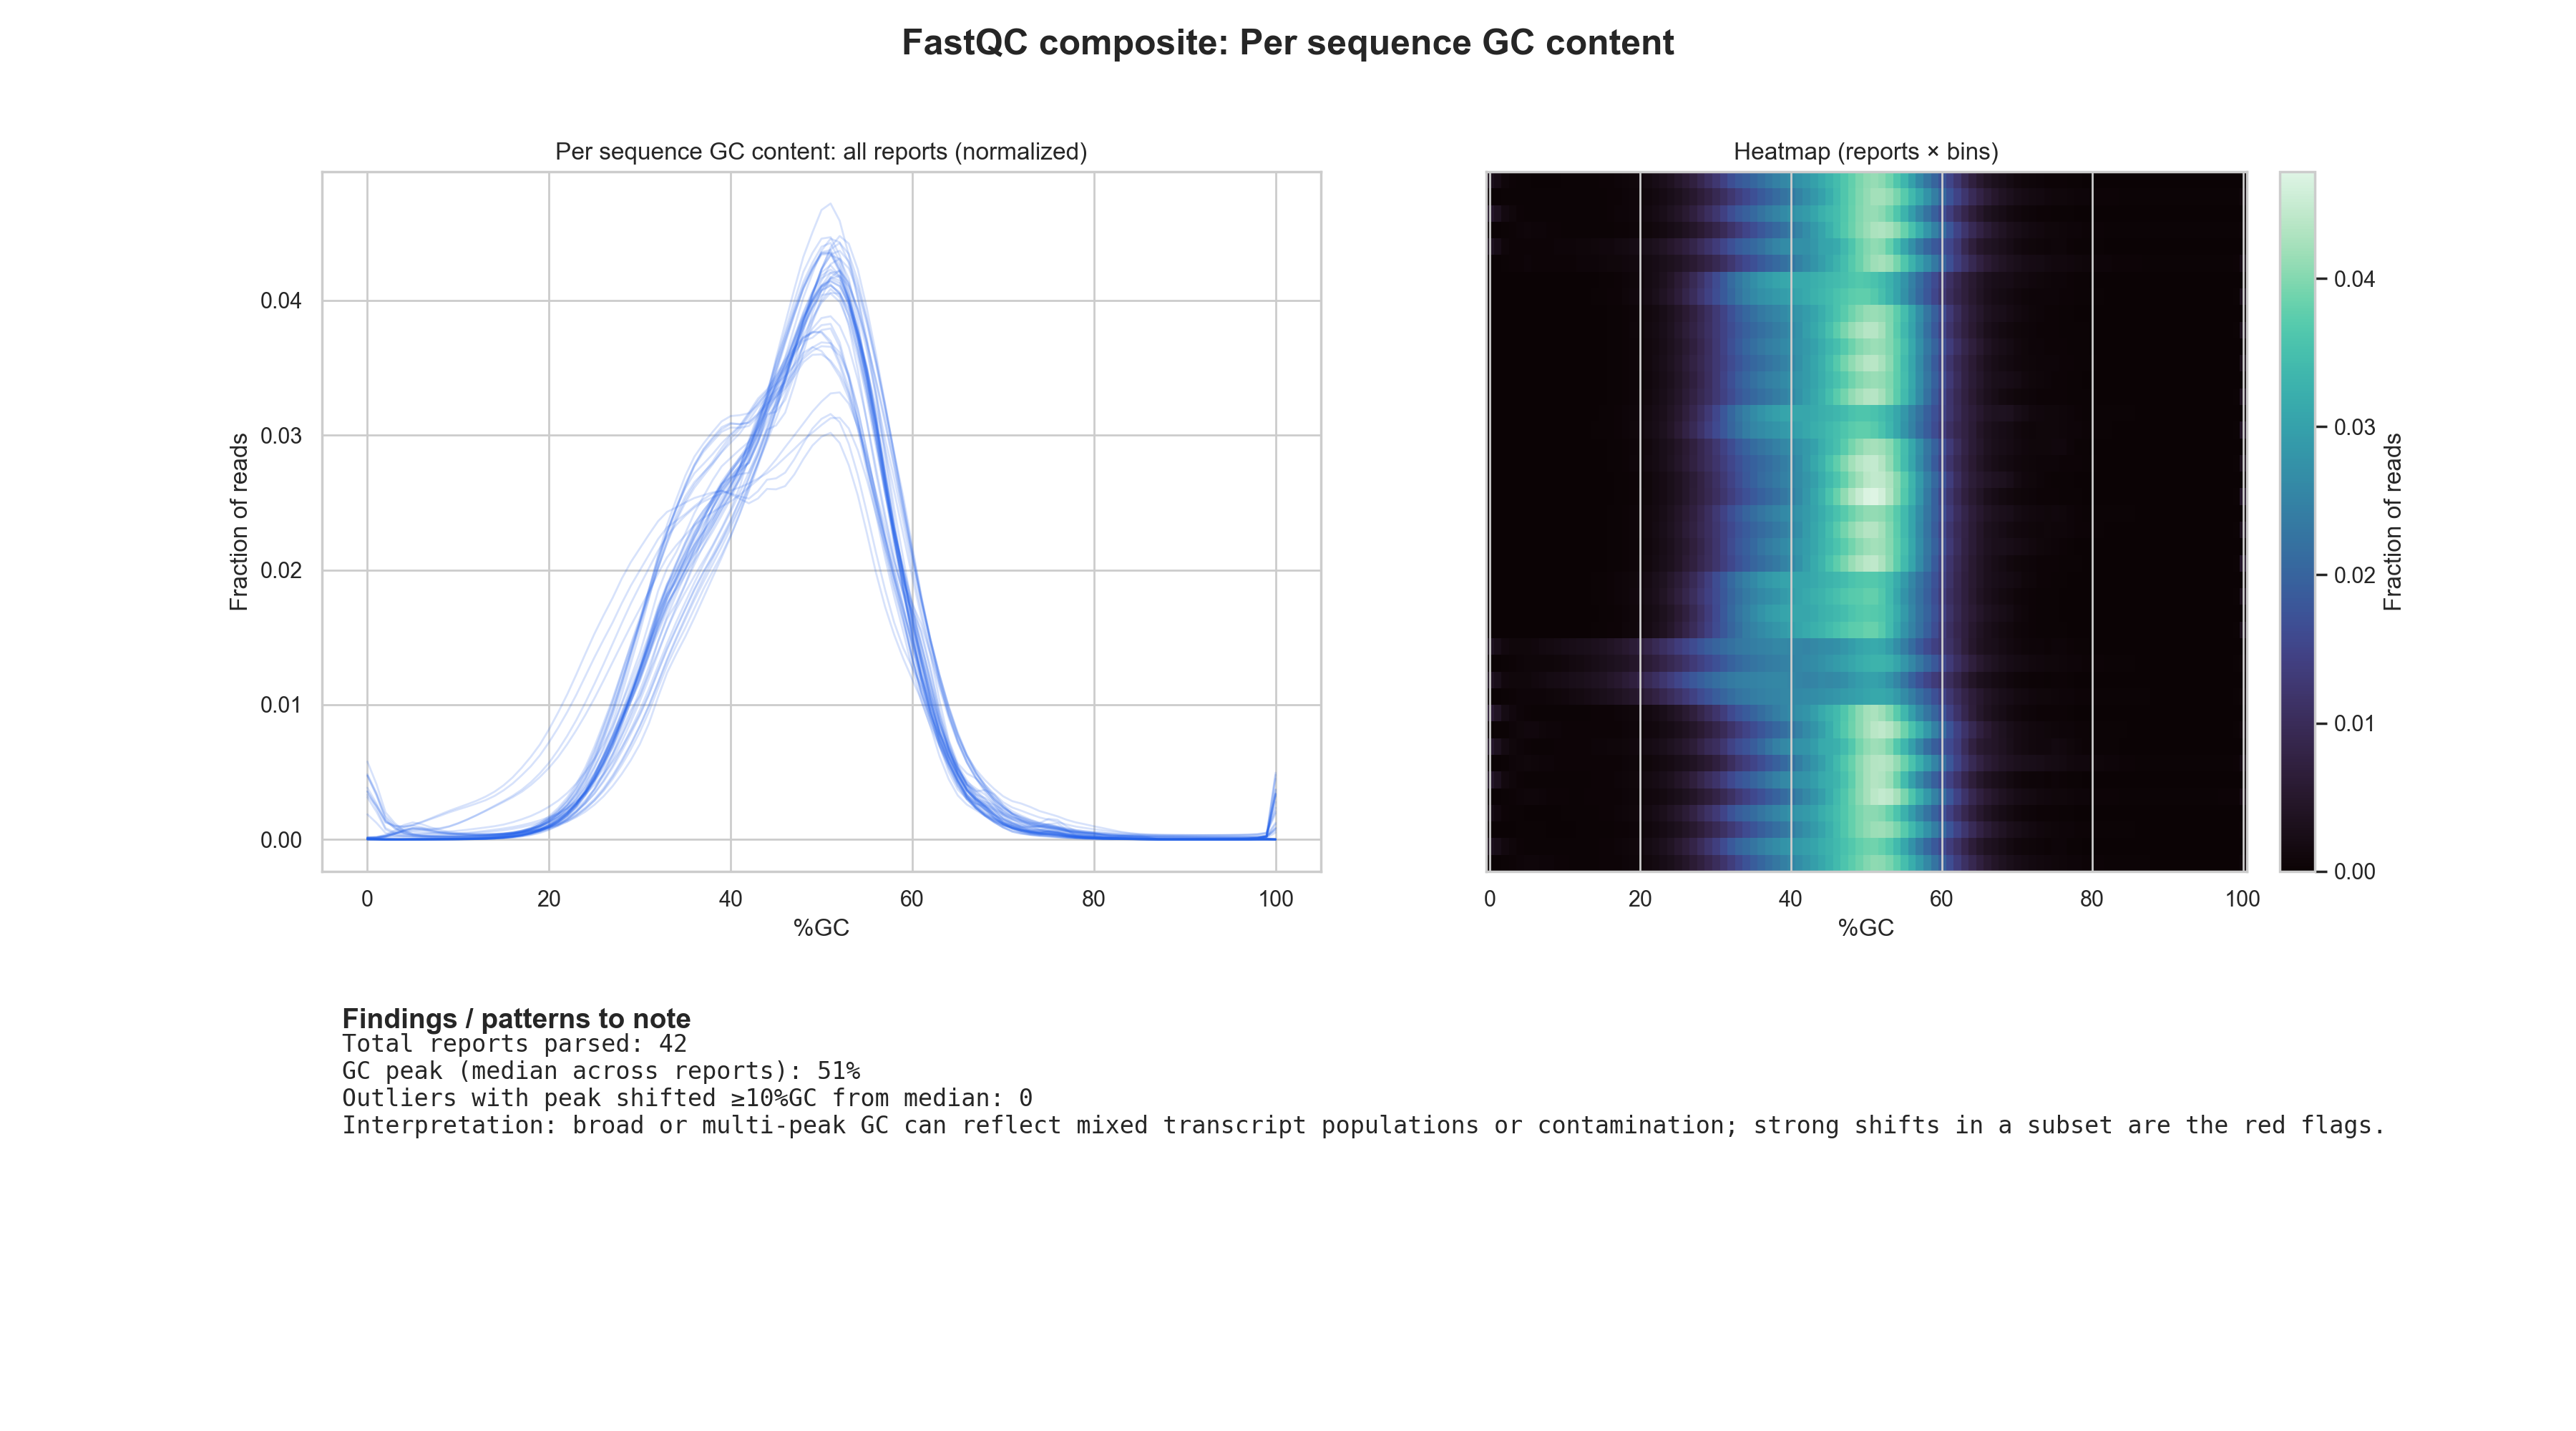

In [14]:
gc_bins = list(range(0, 101))
gc_matrix, gc_meta = build_matrix(
    zips,
    module_name='Per sequence GC content',
    x_col_guess=['GC Content', '%GC', 'GC'],
    y_col_guess=['Count'],
    x_bins=gc_bins
)

if gc_matrix is None:
    raise RuntimeError('No GC content tables found in the FastQC zips')

peaks = summarize_peaks(gc_matrix, gc_bins)
median_peak = int(np.median(peaks))
outliers = int((np.abs(peaks - median_peak) >= 10).sum())

findings = [
    f'Total reports parsed: {gc_matrix.shape[0]}',
    f'GC peak (median across reports): {median_peak}%',
    f'Outliers with peak shifted ≥10%GC from median: {outliers}',
    'Interpretation: broad or multi-peak GC can reflect mixed transcript populations or contamination; strong shifts in a subset are the red flags.',
]

gc_out = out_dir / 'fastqc_per_sequence_gc_content_all.png'
save_composite('Per sequence GC content', gc_matrix, gc_meta, gc_bins, gc_out, x_label='%GC', findings_lines=findings)
gc_out
from pathlib import Path as _Path
display(Image(filename=str(_Path(out_dir) / 'fastqc_per_sequence_gc_content_all.png')))


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_50923/3527745694.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


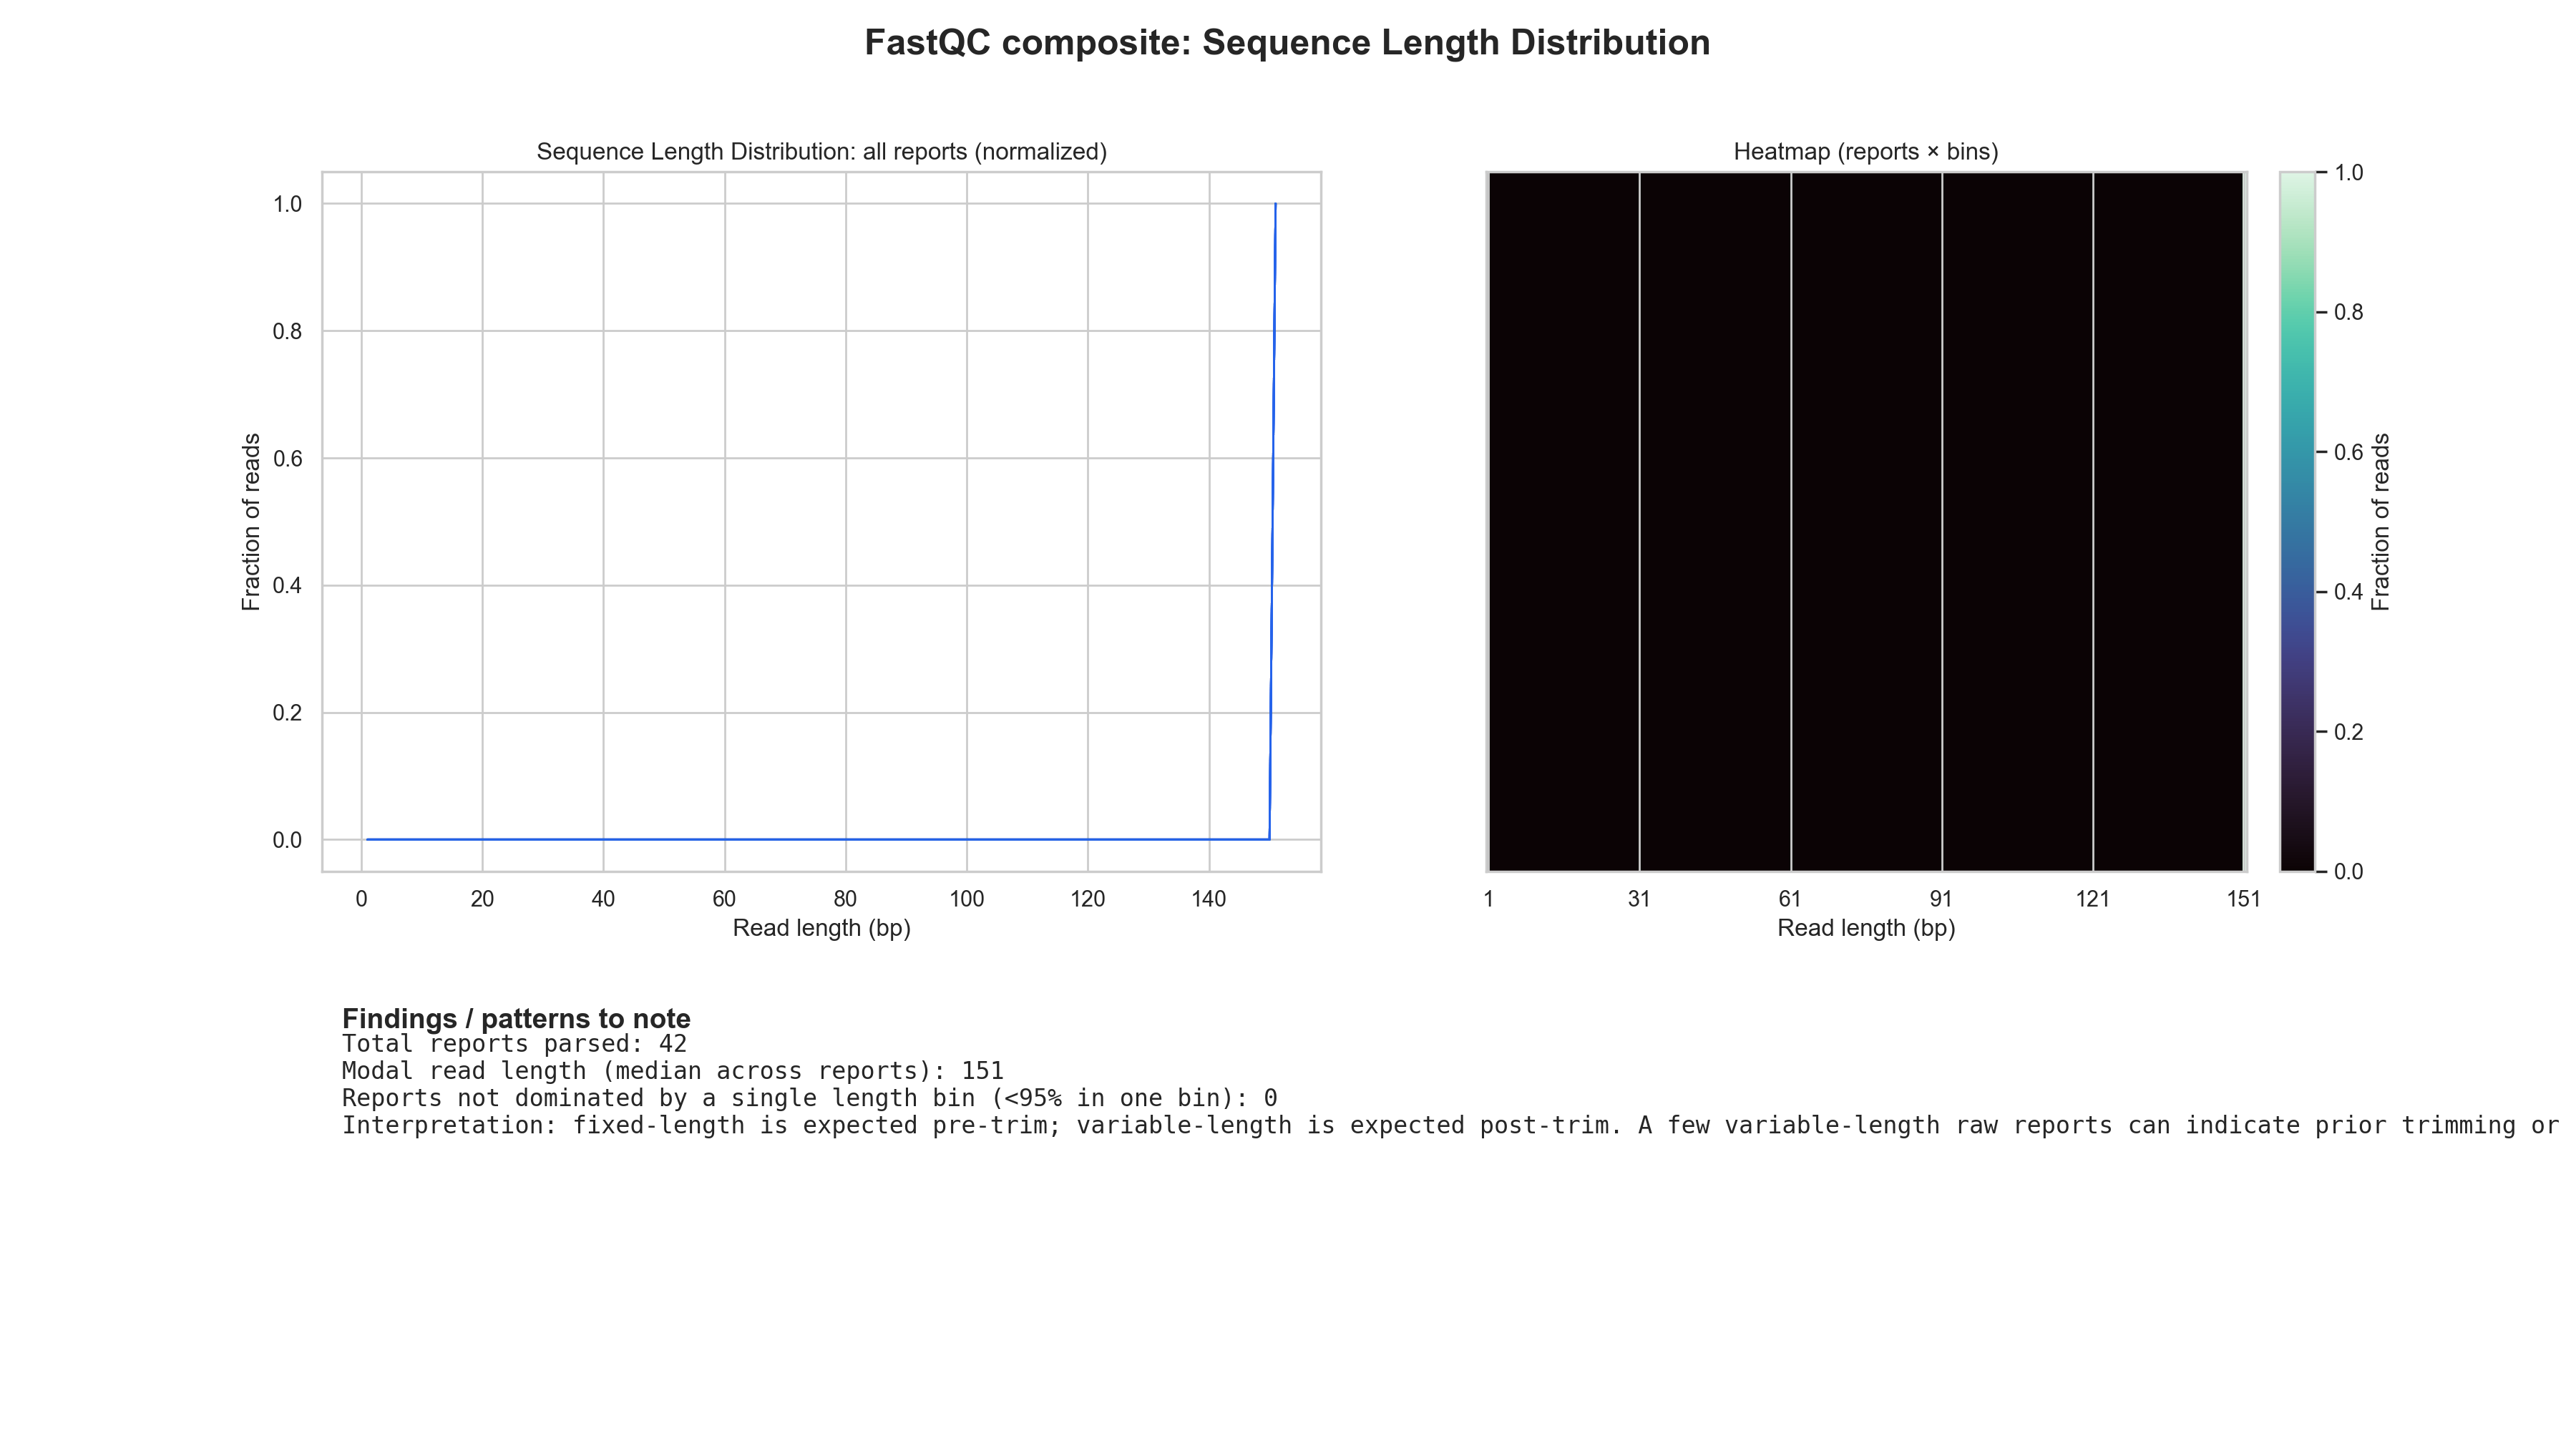

In [15]:
length_tables = []
for zp in zips:
    df = read_module_table_from_zip(zp, 'Sequence Length Distribution')
    if df is None:
        continue
    length_tables.append(df)

if not length_tables:
    raise RuntimeError('No Sequence Length Distribution tables found')

len_df = pd.concat(length_tables, ignore_index=True)
x_col = next((c for c in ['Length', 'Sequence Length'] if c in len_df.columns), None)
y_col = next((c for c in ['Count'] if c in len_df.columns), None)
if not x_col or not y_col:
    raise RuntimeError(f'Unexpected columns in length distribution: {list(len_df.columns)}')

len_df[x_col] = pd.to_numeric(len_df[x_col], errors='coerce')
len_df[y_col] = pd.to_numeric(len_df[y_col], errors='coerce')
max_len = int(np.nanmax(len_df[x_col].values))
length_bins = list(range(1, max_len + 1))

len_matrix, len_meta = build_matrix(
    zips,
    module_name='Sequence Length Distribution',
    x_col_guess=[x_col],
    y_col_guess=[y_col],
    x_bins=length_bins
)

peaks = summarize_peaks(len_matrix, length_bins)
median_len = int(np.median(peaks))
variable = int((len_matrix.max(axis=1) < 0.95).sum())

findings = [
    f'Total reports parsed: {len_matrix.shape[0]}',
    f'Modal read length (median across reports): {median_len}',
    f'Reports not dominated by a single length bin (<95% in one bin): {variable}',
    'Interpretation: fixed-length is expected pre-trim; variable-length is expected post-trim. A few variable-length raw reports can indicate prior trimming or nonstandard processing.',
]

len_out = out_dir / 'fastqc_sequence_length_distribution_all.png'
save_composite('Sequence Length Distribution', len_matrix, len_meta, length_bins, len_out, x_label='Read length (bp)', findings_lines=findings)
len_out
from pathlib import Path as _Path
display(Image(filename=str(_Path(out_dir) / 'fastqc_sequence_length_distribution_all.png')))


/var/folders/7y/f7_vwbw16slft31cvcc6xkk40000gn/T/ipykernel_50923/3527745694.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout(rect=[0, 0, 1, 0.97])


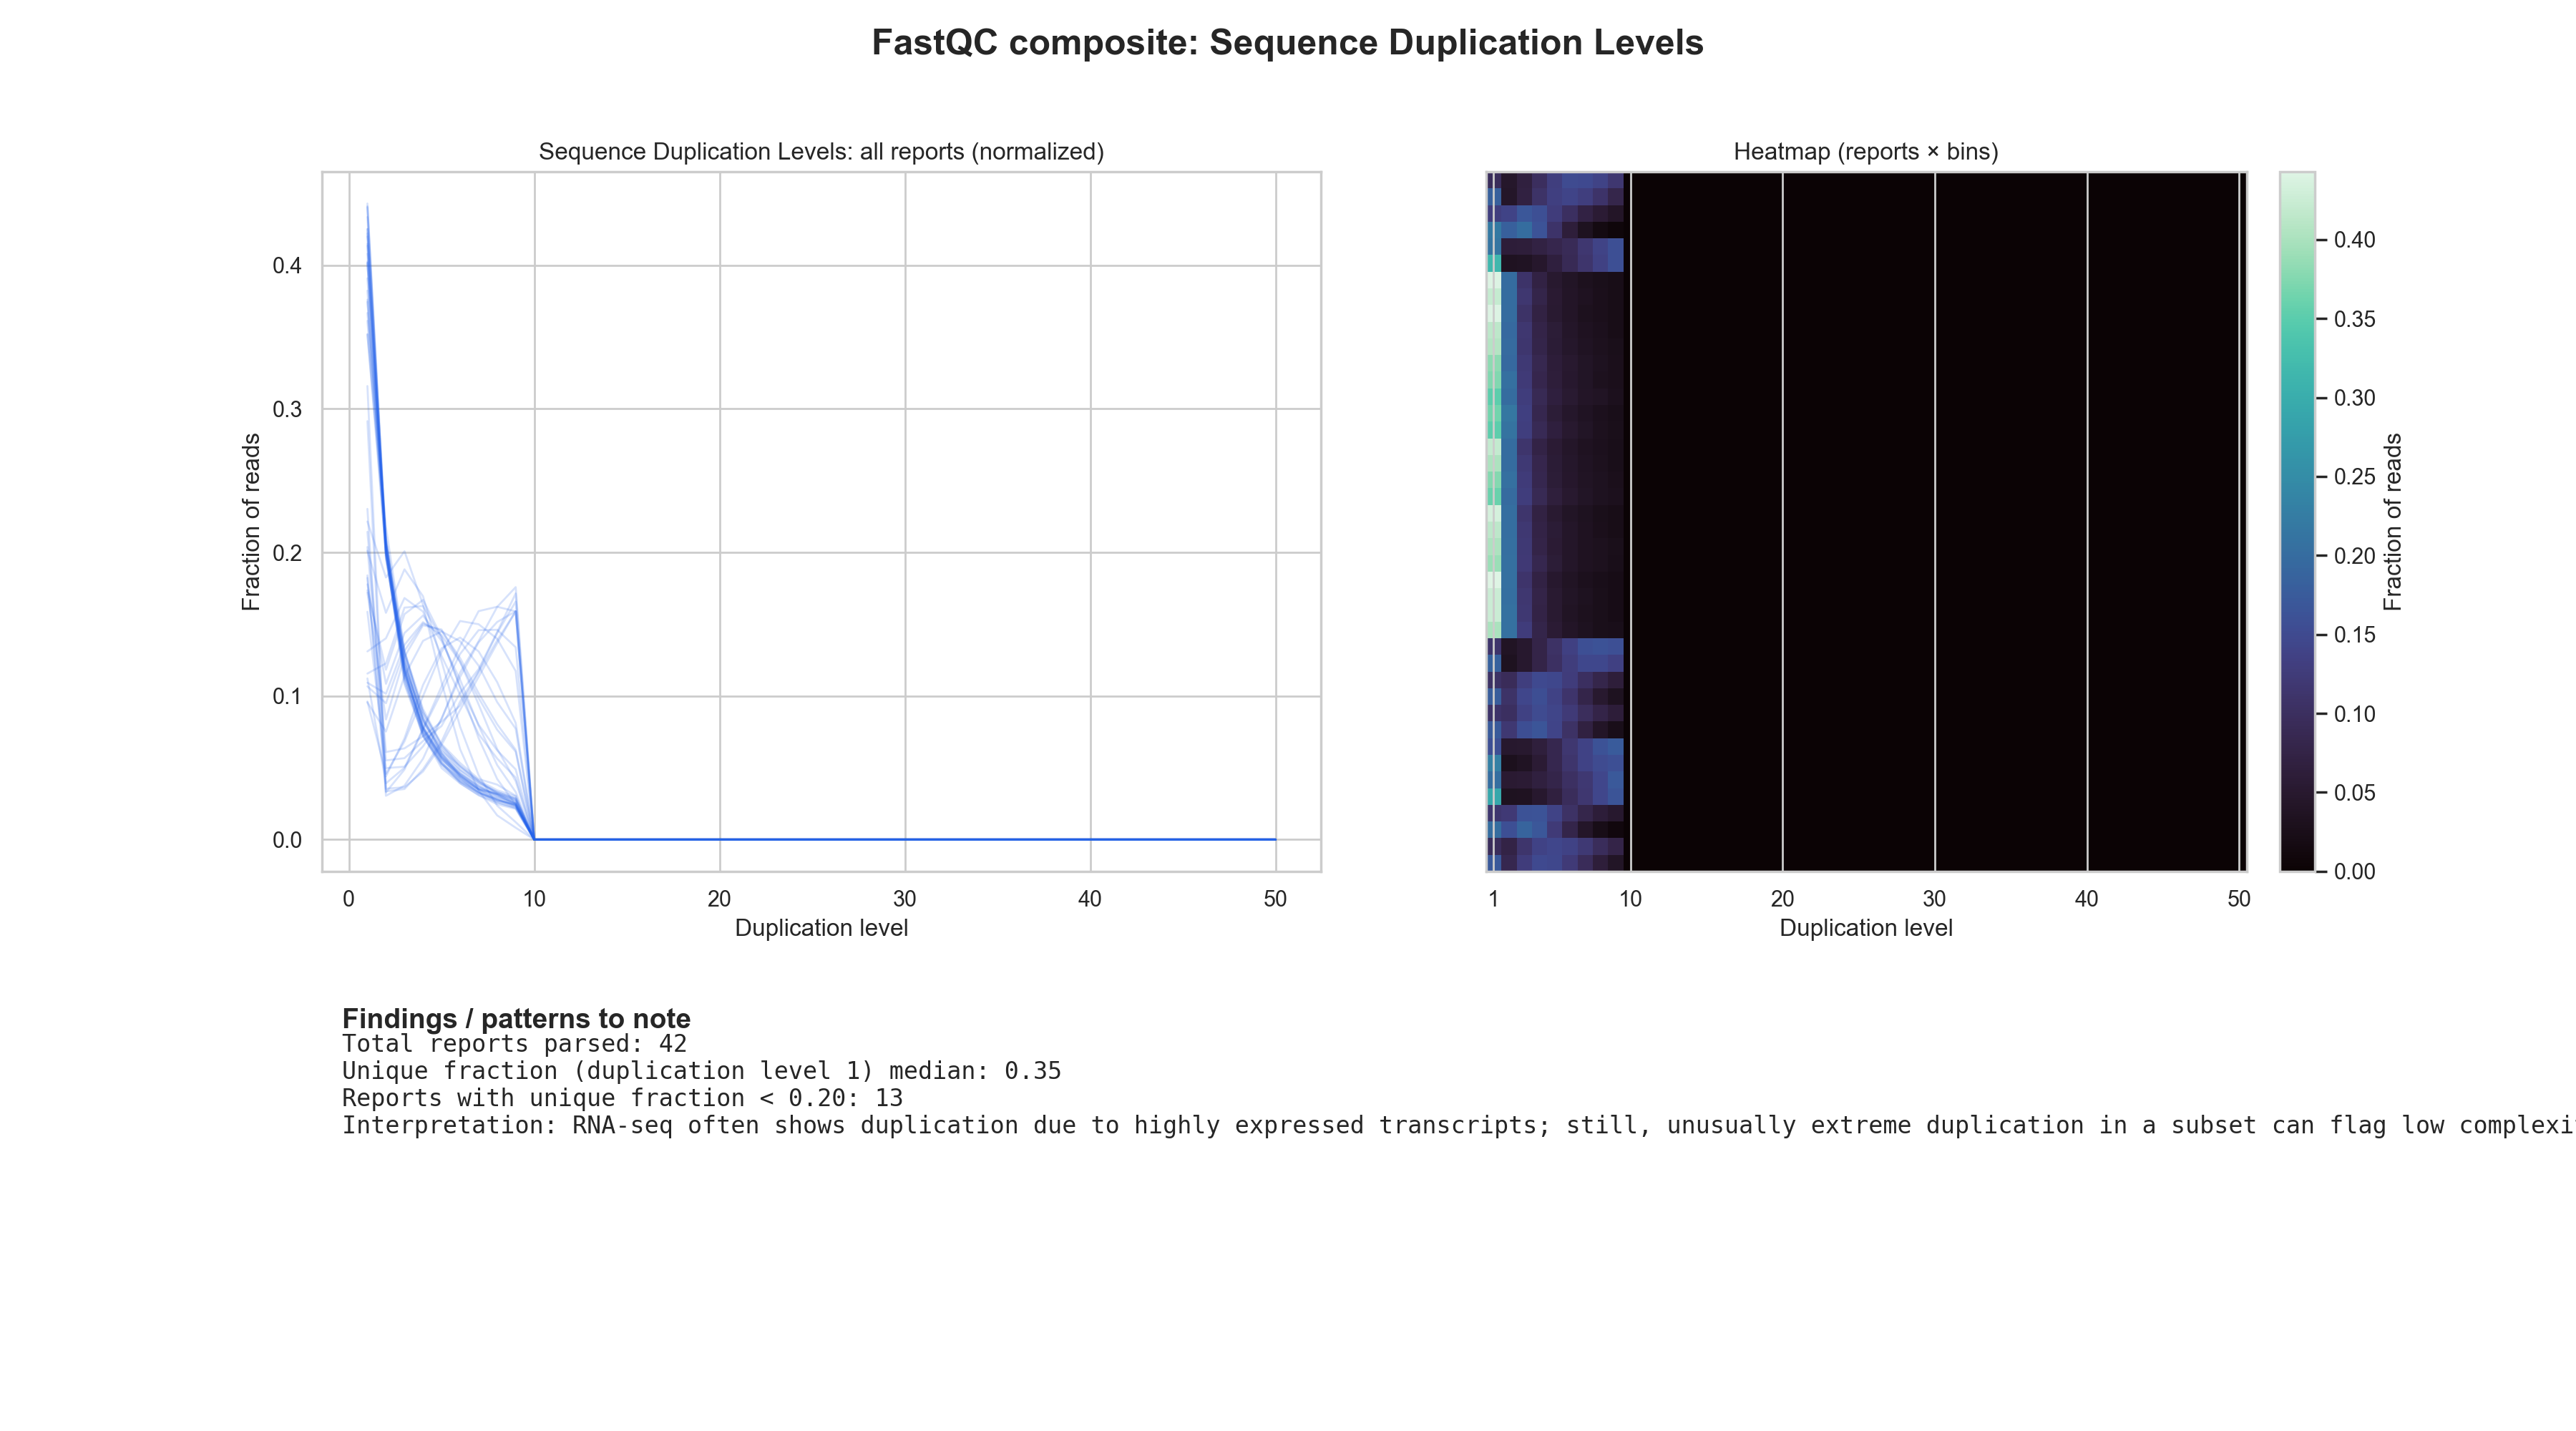

In [16]:
dup_bins = list(range(1, 51))
dup_matrix, dup_meta = build_matrix(
    zips,
    module_name='Sequence Duplication Levels',
    x_col_guess=['Duplication Level'],
    y_col_guess=['Percentage of total'],
    x_bins=dup_bins
)

if dup_matrix is None:
    raise RuntimeError('No duplication tables found')

unique_frac = dup_matrix[:, 0]
median_unique = float(np.median(unique_frac))
low_unique = int((unique_frac < 0.2).sum())

findings = [
    f'Total reports parsed: {dup_matrix.shape[0]}',
    f'Unique fraction (duplication level 1) median: {median_unique:.2f}',
    f'Reports with unique fraction < 0.20: {low_unique}',
    'Interpretation: RNA-seq often shows duplication due to highly expressed transcripts; still, unusually extreme duplication in a subset can flag low complexity or PCR artifacts.',
]

dup_out = out_dir / 'fastqc_sequence_duplication_levels_all.png'
save_composite('Sequence Duplication Levels', dup_matrix, dup_meta, dup_bins, dup_out, x_label='Duplication level', findings_lines=findings)
dup_out
from pathlib import Path as _Path
display(Image(filename=str(_Path(out_dir) / 'fastqc_sequence_duplication_levels_all.png')))


After reportning the cells above, you will have three composite images saved to `qc_bundle/qc_analysis/` and displayed in the notebook.

Use them to answer the team questions:

- Do the GC curves cluster tightly (expected) or split into distinct shapes/peaks (possible mixed populations/contamination)?
- Are read lengths fixed (raw) and variable (trimmed) in the expected way?
- Is duplication uniformly high across samples (common for RNA-seq) or are there clear outliers that may need special handling or re-download?
